In [ ]:
# You must run this code and use this dataset for all questions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
num_students = 50

# Student data
student_ids = np.arange(201, 201 + num_students)
student_ages = np.random.randint(15, 22, num_students)
student_scores = np.random.randint(40, 100, num_students)
student_attendance = np.random.randint(60, 100, num_students)  # percentage

departments_list = [
    "Science",
    "Commerce",
    "Arts",
    "Computer Science",
    "Mathematics",
    "English",
    "Physics",
    "Chemistry",
    "Biology",
    "Economics"
]

student_departments = np.random.choice(departments_list, num_students)

grade_conditions = [
    student_scores >= 80,
    (student_scores >= 65) & (student_scores < 80),
    (student_scores >= 50) & (student_scores < 65),
    student_scores < 50
]
grade_values = ["A", "B", "C", "F"]
student_grades = np.select(grade_conditions, grade_values, default="F")

# Create DataFrame
data = pd.DataFrame({
    "student_id": student_ids,
    "student_age": student_ages,
    "score": student_scores,
    "attendance": student_attendance,
    "department": student_departments,
    "grade": student_grades
})

# Save dataset
data.to_csv("school_data.csv", index=False)

In [46]:
data

,student_id,student_age,score,attendance,department,grade
0,201,21,76,73,Physics,B
1,202,18,90,82,Physics,A
2,203,19,46,99,Biology,F
3,204,21,60,80,Economics,C
4,205,17,48,75,Economics,F
5,206,19,78,77,Arts,B
6,207,19,57,83,Physics,C
7,208,21,43,85,Science,F
8,209,16,64,84,Computer Science,C
9,210,17,99,88,Computer Science,A


In [47]:
score = student_scores
print(score.dtype)
print(score.ndim) 
print(score.shape) 
print(len(score))
attendance=student_attendance
print(attendance.dtype)
print(attendance.ndim) 
print(attendance.shape) 
print(len(attendance))

int32
1
(50,)
50
int32
1
(50,)
50


In [48]:
max_score=np.max(student_scores)
min_score=np.min(student_scores)
avg_score= np.mean(student_scores)
avg_att = np.mean(student_attendance) 
filtered_score = score[score > avg_score] 

print(max_score) 
print(min_score) 
print(avg_att) 
print(filtered_score)


99
41
79.58
[76 90 78 99 89 97 92 86 99 83 86 74 75 89 79 93 81 93 68 83 73 75 70 87]


In [49]:
df = pd.read_csv('school_data.csv') 
df.info() 
df.describe() 
new_df = df[['student_id','student_age','department','grade']] 
new_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   student_id   50 non-null     int64 
 1   student_age  50 non-null     int64 
 2   score        50 non-null     int64 
 3   attendance   50 non-null     int64 
 4   department   50 non-null     object
 5   grade        50 non-null     object
dtypes: int64(4), object(2)
memory usage: 2.5+ KB


,student_id,student_age,department,grade
0,201,21,Physics,B
1,202,18,Physics,A
2,203,19,Biology,F
3,204,21,Economics,C
4,205,17,Economics,F
5,206,19,Arts,B
6,207,19,Physics,C
7,208,21,Science,F
8,209,16,Computer Science,C
9,210,17,Computer Science,A


In [50]:
new_df = new_df.loc[(new_df['student_age'] <= 20) & (new_df['student_age'] >=16)]
new_df = new_df.sort_values('student_id') 
new_df.tail(3)

,student_id,student_age,department,grade
45,246,18,Biology,C
47,248,18,Science,A
49,250,17,Economics,F


In [51]:
df

,student_id,student_age,score,attendance,department,grade
0,201,21,76,73,Physics,B
1,202,18,90,82,Physics,A
2,203,19,46,99,Biology,F
3,204,21,60,80,Economics,C
4,205,17,48,75,Economics,F
5,206,19,78,77,Arts,B
6,207,19,57,83,Physics,C
7,208,21,43,85,Science,F
8,209,16,64,84,Computer Science,C
9,210,17,99,88,Computer Science,A


In [58]:

df['previous_score'] = df['score']
def grade_incraese(df):
    df['new_score'] = df['score']
    df.loc[(df['department'] == 'Mathematics') | (df['department'] == 'Computer Science'),'new_score']= df['new_score'] + (df['new_score'] * 0.10)  

    df.loc[(df['department'] != 'Mathematics') & (df['department'] != 'Computer Science'),'new_score']= df['new_score'] + (df['new_score'] * 0.05)

    df.loc[df['new_score'] >100,'new_score']=100
    return df


df = grade_incraese(df)


df['score_increase'] = df['new_score'] - df['score']

new_df = df[['student_id','department','previous_score','new_score','score_increase']]
new_df

        

C:\Users\sanim\AppData\Local\Temp\ipykernel_30440\3641785303.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 70.4 108.9  58.3  52.8 108.9  91.3  47.3  74.8  77. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[(df['department'] == 'Mathematics') | (df['department'] == 'Computer Science'),'new_score']= df['new_score'] + (df['new_score'] * 0.10)


,student_id,department,previous_score,new_score,score_increase
0,201,Physics,76,79.80,3.80
1,202,Physics,90,94.50,4.50
2,203,Biology,46,48.30,2.30
3,204,Economics,60,63.00,3.00
4,205,Economics,48,50.40,2.40
5,206,Arts,78,81.90,3.90
6,207,Physics,57,59.85,2.85
7,208,Science,43,45.15,2.15
8,209,Computer Science,64,70.40,6.40
9,210,Computer Science,99,100.00,1.00


Text(0.5, 1.0, 'Average Score by Department')

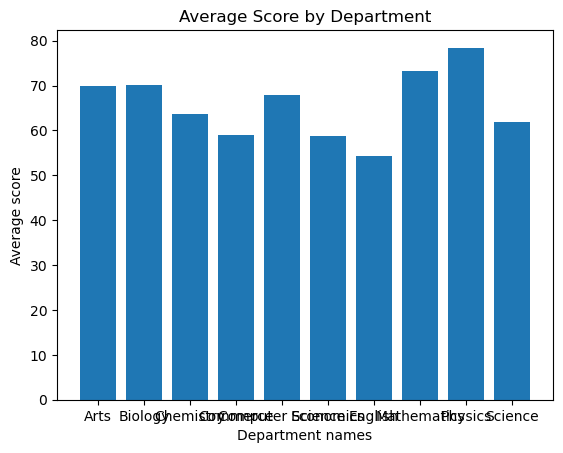

In [63]:
avg_score = df.groupby('department')['score'].mean() 

plt.bar(avg_score.index,avg_score.values)
plt.xlabel('Department names')
plt.ylabel('Average score')
plt.title('Average Score by Department')


Text(0.5, 1.0, 'Distribution of Student Scores')

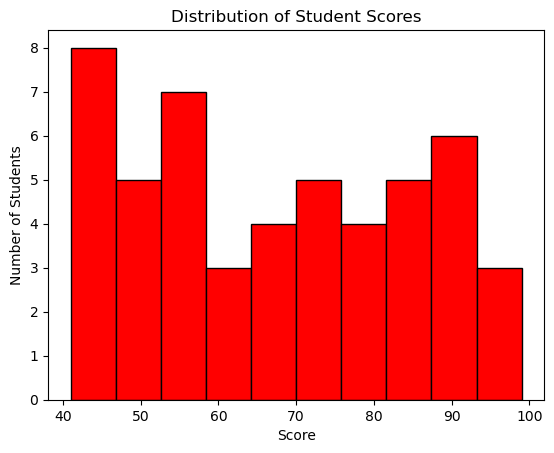

In [65]:
plt.hist(df['score'],color='red',edgecolor='black',bins=10)
plt.xlabel('Score') 
plt.ylabel('Number of Students')
plt.title('Distribution of Student Scores')

Text(0.5, 1.0, 'Attendance vs Score')

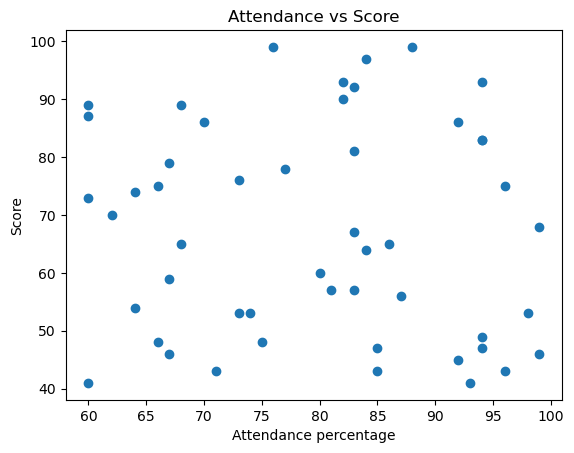

In [66]:
plt.scatter(df['attendance'],df['score']) 
plt.xlabel('Attendance percentage') 
plt.ylabel('Score') 
plt.title('Attendance vs Score')

Text(0.5, 1.0, 'Score Distribution by Grade')

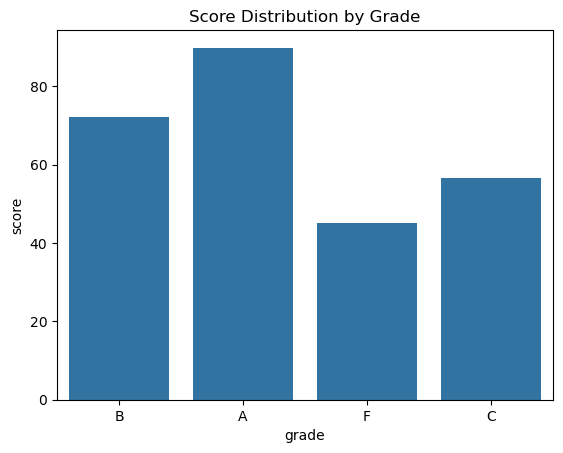

In [68]:
sns.barplot(data=df,x='grade',y='score',errorbar=None)
plt.title('Score Distribution by Grade')

Text(0.5, 1.0, 'Number of Students per Department')

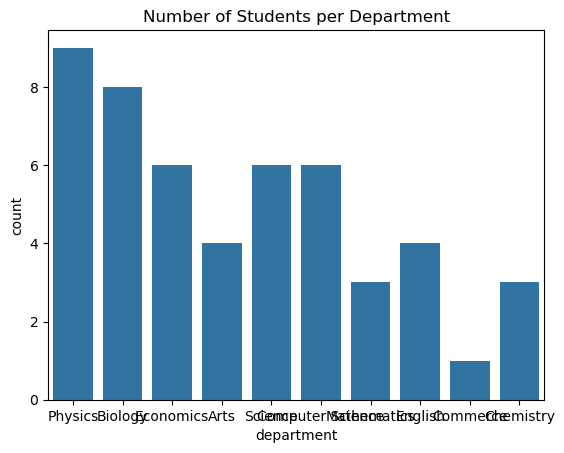

In [69]:
sns.countplot(data=df,x='department')
plt.title('Number of Students per Department')

Text(0, 0.5, 'Score')

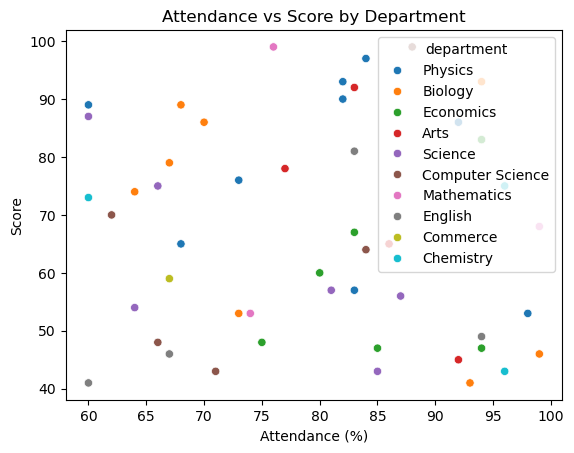

In [70]:
sns.scatterplot(data=df,x='attendance',y='score',hue='department') 
plt.title('Attendance vs Score by Department') 
plt.xlabel('Attendance (%)') 
plt.ylabel('Score')